In [1]:
import sys
from pathlib import Path

_root = Path.cwd().resolve()
while not (_root / ".git").exists():
    if _root == _root.parent:
        raise FileNotFoundError("Could not locate project root (.git not found)")
    _root = _root.parent
sys.path.insert(0, str(_root))

from config import RAW_DATASET_PATH
import pandas as pd

df = pd.read_csv(RAW_DATASET_PATH)
print(f"Loaded {len(df):,} rows, {len(df.columns)} columns from {RAW_DATASET_PATH}")
df.head()

Loaded 100,000 rows, 22 columns from C:\Users\hamna\Desktop\MediAlert\data\raw\medical_dataset.csv


,patient_id,admission_date,discharge_date,age,sex,bmi,systolic_bp,diastolic_bp,cholesterol,hdl,...,creatinine,hemoglobin,wbc,smoking_status,alcohol_use,diabetes,hypertension,primary_diagnosis,medications,readmission_30
0,75722,27/08/2021 12:52,03/09/2021 12:52,44,Female,24.5,131,94,182,53,...,0.57,15.9,8.9,Never,Never,1,1,Diabetes;Hypertension,DPP4 inhibitor;Thiazide,1
1,80185,27/01/2025 23:11,03/02/2025 23:11,61,Male,31.4,101,57,248,54,...,1.07,15.2,3.3,Never,Occasional,1,1,Diabetes;Hypertension,Insulin;Calcium channel blocker,1
2,19865,09/05/2022 13:47,19/05/2022 13:47,81,Female,23.3,150,87,149,41,...,1.23,16.4,7.8,Never,Occasional,1,1,Diabetes;Hypertension,DPP4 inhibitor;Thiazide,1
3,76700,17/12/2022 19:04,24/12/2022 19:04,47,Male,33.3,135,98,272,42,...,1.25,13.8,9.3,Never,Occasional,0,1,Hypertension,Calcium channel blocker,0
4,92992,02/03/2024 07:50,13/03/2024 07:50,89,Male,34.7,121,84,217,69,...,1.75,13.3,7.7,Current,Regular,1,1,Diabetes;Hypertension,Sulfonylurea;Calcium channel blocker,0


In [2]:
print("=== Missing values ===")
missing = df.isnull().sum()
print(missing[missing > 0])
print()

print("=== Dtypes and non-null counts ===")
df.info()

=== Missing values ===
medications    13878
dtype: int64

=== Dtypes and non-null counts ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 22 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   patient_id         100000 non-null  int64  
 1   admission_date     100000 non-null  object 
 2   discharge_date     100000 non-null  object 
 3   age                100000 non-null  int64  
 4   sex                100000 non-null  object 
 5   bmi                100000 non-null  float64
 6   systolic_bp        100000 non-null  int64  
 7   diastolic_bp       100000 non-null  int64  
 8   cholesterol        100000 non-null  int64  
 9   hdl                100000 non-null  int64  
 10  ldl                100000 non-null  int64  
 11  glucose            100000 non-null  int64  
 12  creatinine         100000 non-null  float64
 13  hemoglobin         100000 non-null  float64
 14  wbc     

In [3]:
diabetic_df = df[df['diabetes'] == 1].copy()
print(f"Full dataset: {len(df):,} rows")
print(f"Diabetic cohort: {len(diabetic_df):,} rows ({len(diabetic_df)/len(df)*100:.1f}%)")

Full dataset: 100,000 rows
Diabetic cohort: 62,232 rows (62.2%)


In [4]:
print("=== Readmission class balance within diabetic cohort ===")
counts = diabetic_df['readmission_30'].value_counts()
pcts = diabetic_df['readmission_30'].value_counts(normalize=True) * 100
for cls in counts.index:
    print(f"Class {cls}: {counts[cls]:,} ({pcts[cls]:.1f}%)")

=== Readmission class balance within diabetic cohort ===
Class 1: 32,609 (52.4%)
Class 0: 29,623 (47.6%)


In [5]:
for col in ['sex', 'smoking_status', 'alcohol_use', 'primary_diagnosis']:
    print(f"\n{col}:")
    print(diabetic_df[col].value_counts(dropna=False))


sex:
sex
Female    31162
Male      29851
Other      1219
Name: count, dtype: int64

smoking_status:
smoking_status
Never      37393
Former     15443
Current     9396
Name: count, dtype: int64

alcohol_use:
alcohol_use
Occasional    28119
Never         24864
Regular        9249
Name: count, dtype: int64

primary_diagnosis:
primary_diagnosis
Diabetes;Hypertension    37852
Diabetes                 24380
Name: count, dtype: int64


In [6]:
diabetic_df.describe()

,patient_id,age,bmi,systolic_bp,diastolic_bp,cholesterol,hdl,ldl,glucose,creatinine,hemoglobin,wbc,diabetes,hypertension,readmission_30
count,62232.000000,62232.000000,62232.000000,62232.000000,62232.000000,62232.000000,62232.000000,62232.000000,62232.000000,62232.000000,62232.00000,62232.000000,62232.0,62232.000000,62232.000000
mean,50039.181305,54.240937,27.983219,126.415751,78.389141,200.240921,49.948387,130.708269,106.427160,1.021958,13.46084,7.003468,1.0,0.608240,0.523991
std,28838.125178,16.942640,5.880137,18.551982,11.073145,40.019344,11.937734,41.869153,29.026034,0.308712,1.51294,1.985802,0.0,0.488147,0.499428
min,1.000000,0.000000,12.000000,80.000000,40.000000,100.000000,20.000000,50.000000,50.000000,0.300000,7.00000,2.000000,1.0,0.000000,0.000000
25%,25023.250000,43.000000,24.000000,114.000000,71.000000,173.000000,42.000000,101.000000,86.000000,0.810000,12.40000,5.700000,1.0,0.000000,0.000000
50%,50112.500000,54.000000,28.000000,126.000000,78.000000,200.000000,50.000000,130.000000,106.000000,1.020000,13.50000,7.000000,1.0,1.000000,1.000000
75%,74972.500000,66.000000,32.000000,139.000000,86.000000,227.000000,58.000000,159.000000,126.000000,1.230000,14.50000,8.300000,1.0,1.000000,1.000000
max,100000.000000,100.000000,56.000000,200.000000,123.000000,386.000000,100.000000,300.000000,225.000000,2.300000,18.00000,15.700000,1.0,1.000000,1.000000


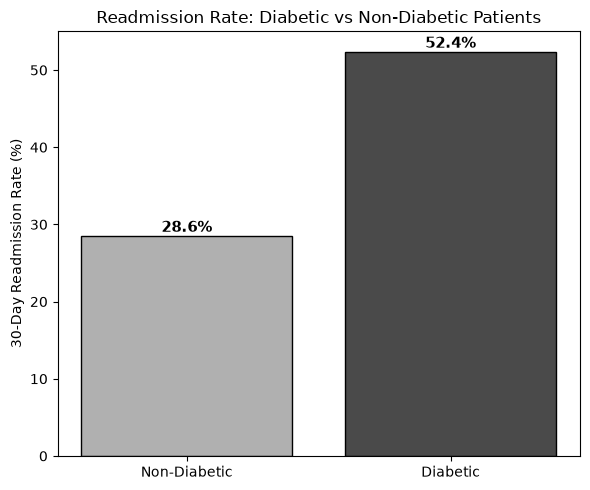

Non-diabetic: 28.6% | Diabetic: 52.4%
Diabetic patients are 1.8x more likely to be readmitted within 30 days


In [7]:
import matplotlib.pyplot as plt

readmit_by_diabetes = df.groupby('diabetes')['readmission_30'].mean() * 100

fig, ax = plt.subplots(figsize=(6, 5))
labels = ['Non-Diabetic', 'Diabetic']
values = [readmit_by_diabetes.get(0, 0), readmit_by_diabetes.get(1, 0)]
bars = ax.bar(labels, values, color=['#B0B0B0', '#4A4A4A'], edgecolor='black', linewidth=1)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.5, f'{val:.1f}%', ha='center', fontsize=11, weight='bold')
ax.set_ylabel('30-Day Readmission Rate (%)')
ax.set_title('Readmission Rate: Diabetic vs Non-Diabetic Patients')
plt.tight_layout()
plt.savefig('../results/figures/eda_readmission_by_diabetes.png', dpi=150)
plt.show()

print(f"Non-diabetic: {values[0]:.1f}% | Diabetic: {values[1]:.1f}%")
print(f"Diabetic patients are {values[1]/values[0]:.1f}x more likely to be readmitted within 30 days")

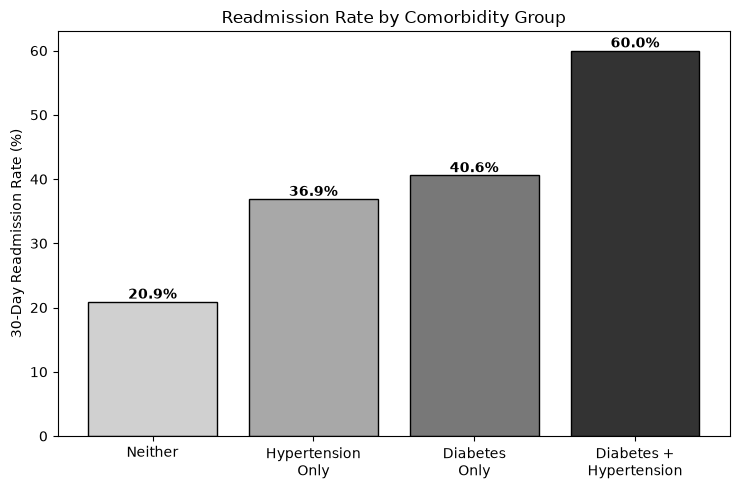

{'Neither': 20.9, 'Hypertension\nOnly': 36.9, 'Diabetes\nOnly': 40.6, 'Diabetes +\nHypertension': 60.0}


In [8]:
def comorbidity_group(row):
    if row['diabetes'] == 1 and row['hypertension'] == 1:
        return 'Diabetes +\nHypertension'
    elif row['diabetes'] == 1:
        return 'Diabetes\nOnly'
    elif row['hypertension'] == 1:
        return 'Hypertension\nOnly'
    else:
        return 'Neither'

df['comorbidity_group'] = df.apply(comorbidity_group, axis=1)
group_order = ['Neither', 'Hypertension\nOnly', 'Diabetes\nOnly', 'Diabetes +\nHypertension']
readmit_by_group = df.groupby('comorbidity_group')['readmission_30'].mean().reindex(group_order) * 100

fig, ax = plt.subplots(figsize=(7.5, 5))
colors = ['#D0D0D0', '#A8A8A8', '#787878', '#333333']
bars = ax.bar(readmit_by_group.index, readmit_by_group.values, color=colors, edgecolor='black', linewidth=1)
for bar, val in zip(bars, readmit_by_group.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.5, f'{val:.1f}%', ha='center', fontsize=10, weight='bold')
ax.set_ylabel('30-Day Readmission Rate (%)')
ax.set_title('Readmission Rate by Comorbidity Group')
plt.tight_layout()
plt.savefig('../results/figures/eda_readmission_by_comorbidity.png', dpi=150)
plt.show()

print(readmit_by_group.round(1).to_dict())

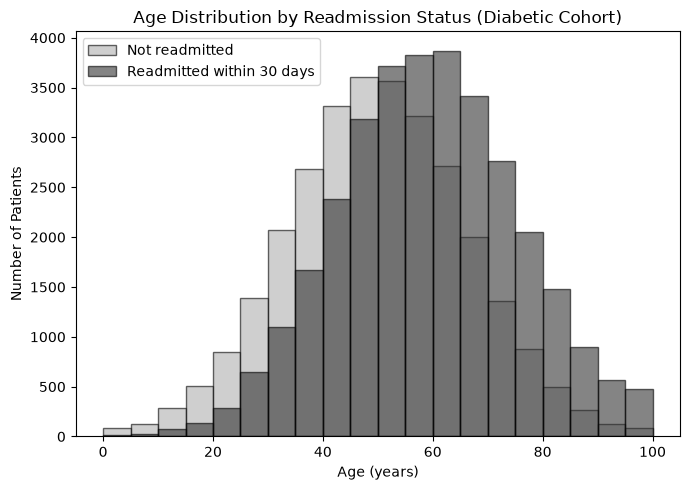

In [9]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.hist(diabetic_df[diabetic_df['readmission_30']==0]['age'], bins=20, alpha=0.6,
        label='Not readmitted', color='#B0B0B0', edgecolor='black')
ax.hist(diabetic_df[diabetic_df['readmission_30']==1]['age'], bins=20, alpha=0.6,
        label='Readmitted within 30 days', color='#333333', edgecolor='black')
ax.set_xlabel('Age (years)')
ax.set_ylabel('Number of Patients')
ax.set_title('Age Distribution by Readmission Status (Diabetic Cohort)')
ax.legend()
plt.tight_layout()
plt.savefig('../results/figures/eda_age_by_readmission.png', dpi=150)
plt.show()